In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import optimize

L’esercitazione prende in esame una serie di dati dell’esperimento CMS al CERN riguardanti il decadimento del mesone $J/\ \psi$ in una coppia di particelle e antiparticelle muoniche $\mu\mu$ : decadimento $ J/\ \psi \rightarrow\ \mu\mu $.

Secondo la teoria della Relatività Ristretta il modulo del quadrimpuso è una invariante per trasformazioni di Lorentz:
$$ mc^2 = \sqrt{ E^2 - (p_x^2 + p_y^2 + p_z^2)} $$
Nel caso di un decadimento si può calcolare la massa invariante della particella decaduta a partire dai prodotti di decadimento.

Per un decadimento a due corpi, come al caso di studio, abbiamo:
$$ mc^2 = \sqrt{ (E_1 + E_2)^2 - \left( (p_{x1}+p_{x2})^2 + (p_{y1}+p_{y2})^2 + (p_{z1}+p_{z2})^2 \right)} $$

Questa massa dovrebbe essere, come previsto dalla teoria, costante per ciascun decadimento e quindi per ciascuna coppia di particelle prodotte (muoni). Tuttavia, un picco nella distribuzione delle masse invarianti per questo tipo di decadimento permise di individuare una particella mesonica costituita da una un quark charm ed un anti-quark charm e quindi di scoprire un nuovo sapore, il charm appunto.

### Distribuzione delle massa ivarianti
Calcolare la massa invariante per ogni evento di decadimento e produrre un istogramma della massa invariante calcolata.

In [ ]:
dataset= pd.read_csv('/home/nicola_polito/MCF/dati/dati-e7/Jpsi_mumu.csv', sep=',')
dataset

,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,165617,75206813,G,10.1623,0.4763,-8.5164,5.5231,8.5297,0.6091,-1.5149,-1,G,19.7754,2.7508,-13.9871,13.7059,14.2550,0.8539,-1.3766,1
1,165617,75678475,G,15.8799,15.0618,-1.6658,-4.7464,15.1536,-0.3083,-0.1102,1,G,11.9338,11.9084,-0.7670,-0.0851,11.9330,-0.0071,-0.0643,-1
2,165617,74428554,G,21.8279,-6.2214,11.0845,17.7447,12.7111,1.1357,2.0823,-1,G,36.6513,-10.6874,15.0692,31.6544,18.4743,1.3076,2.1877,1
3,165617,75193169,G,19.4923,2.7612,-5.5769,-18.4719,6.2230,-1.8084,-1.1111,1,G,14.9334,1.5525,-6.1254,-13.5302,6.3190,-1.5050,-1.3226,-1
4,165617,74832715,G,8.0972,4.6127,-1.8389,6.3949,4.9657,1.0710,-0.3793,-1,T,3.5131,-0.5305,0.6880,3.4024,0.8688,2.0742,2.2276,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,163796,127190648,G,20.3600,9.1811,7.6371,-16.4894,11.9423,-1.1267,0.6939,-1,G,8.1878,4.2811,4.4597,-5.3678,6.1819,-0.7851,0.8058,1
19996,163796,127218144,G,11.4697,-1.6944,6.4898,-9.3035,6.7073,-1.1304,1.8262,-1,G,12.0051,-2.2652,9.0200,-7.5908,9.3001,-0.7453,1.8168,1
19997,163796,127418342,G,7.8173,4.7081,-4.8603,-3.9128,6.7668,-0.5501,-0.8013,1,G,10.7875,7.8230,-3.5396,-6.5291,8.5865,-0.7014,-0.4249,-1
19998,163796,127439838,G,11.2399,-8.7510,-5.7406,-4.0975,10.4658,-0.3821,-2.5610,1,G,17.7455,-12.2635,-11.9949,-4.5412,17.1543,-0.2617,-2.3673,-1


In [3]:
##MASSA INVARIANTE
def mc2(e,p1,p2):
    """Calcola la massa invariante di un decadimento a due corpi.

    Parametri:
    ---------
    e: list of float
        lista con valori dell'energia per ciascuna particella;
    p1,p2: list of float
        lista con valori della quantità di moto delle due particelle per ciascuna componente;

    Restituisce:
    -----------
    t3: float
        modulo del quadrimpulso di ciascuna coppia di prodotto di decadimento.
    """
    t3=0
    t1= (e[0] + e[1])**2
    t=np.empty(0)
    for j in range(3):
        t=np.append(t, (p1[j]+p2[j])**2)
    t2=np.sum(t)
    if((t1-t2)>0):
        t3=np.sqrt(t1-t2)
    else:
        t3=0
        print('Values Error!')
    return t3

#prova
help(mc2)
d=mc2([5,4], [1,2,3], [1,2,3])
print(d)

Help on function mc2 in module __main__:

mc2(e, p1, p2)
    Calcola la massa invariante di un decadimento a due corpi.
    
    Parametri:
    ---------
    e: list of float
        lista con valori dell'energia per ciascuna particella;
    p1,p2: list of float
        lista con valori della quantità di moto delle due particelle per ciascuna componente;
    
    Restituisce:
    -----------
    t3: float
        modulo del quadrimpulso di ciascuna coppia di prodotto di decadimento.

5.0


In [4]:
#valori di energia e impulso dai dati
E1=np.array(dataset['E1'], dtype=float)
E2=np.array(dataset['E2'], dtype=float)
E=np.array([E1, E2])

#print(E)

#p1=np.array([dataset['px1'], dataset['py1'], dataset['pz1']])
#p2=np.array([dataset['px2'], dataset['py2'], dataset['pz2']])
P1 =np.array(dataset[['px1','py1','pz1']], dtype=float)
P2 =np.array(dataset.loc[:,['px2','py2','pz2']], dtype=float)

#print(P1)
#print(P2)

print('1° decadimento: E1= ', E[0,0], 'E2= ', E[1,0] , 'p1= ', P1[0], ' p2= ', P2[0])

1° decadimento: E1=  10.1623 E2=  19.7754 p1=  [ 0.4763 -8.5164  5.5231]  p2=  [  2.7508 -13.9871  13.7059]


In [5]:
#Calcolo distribuzione masse invarianti:
d_m=np.empty(0)
for j in range(P1.shape[0]):
    mass_inv=mc2(E[:,j], P1[j], P2[j])
    d_m=np.append(d_m, mass_inv)

print(len(d_m))

20000


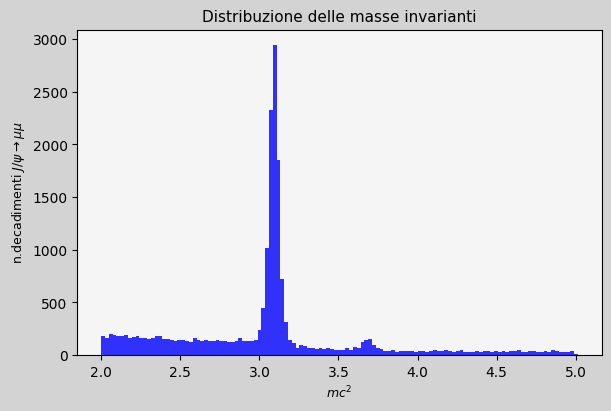

In [6]:
#Istogramma delle masse invarianti
fig1, ax1 = plt.subplots(1,1, figsize=(6,4), layout='constrained', facecolor='lightgrey')
nd, bins, p = ax1.hist(d_m, bins=125, color='blue', alpha=0.8)
ax1.set_facecolor('whitesmoke')
ax1.set_title('Distribuzione delle masse invarianti', fontsize=11)
ax1.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=9)
ax1.set_xlabel(r'$mc^2$', fontsize=9)
plt.show()

Text(3.02, 260, '      ')

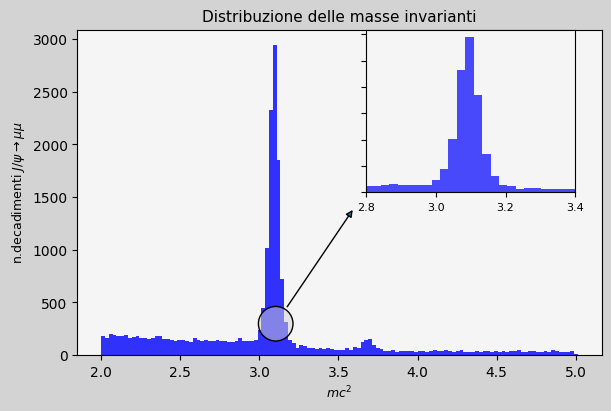

In [ ]:
#Istogramma delle masse invarianti con inserto sul picco
fig2, ax2 = plt.subplots(1,1, figsize=(6,4), layout='constrained', facecolor='lightgrey')
ax2.hist(d_m, bins=125, color='blue', alpha=0.8)
ax2.set_facecolor('whitesmoke')
ax2.set_title('Distribuzione delle masse invarianti', fontsize=11)
ax2.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=9)
ax2.set_xlabel(r'$mc^2$', fontsize=9)

#inserto
ins=ax2.inset_axes([0.55, 0.5, 0.4, 0.5], facecolor='whitesmoke')
ins.hist(d_m, bins=125, color='blue', alpha=0.7)
ins.set_xlim(2.8, 3.4)
ins.tick_params(labelleft=False, labelsize=8)
ins.set_xticks([2.8, 3.0, 3.2, 3.4])

#freccia
fc = colors.to_rgba('lightgrey')  # facecolor
ec = colors.to_rgba('black')      # edgecolor

# Imposta alpha solo per il facecolor
fc = fc[:-1] + (0.5,)  # 0.5 = 50% trasparente
ax2.annotate("      ", xytext=(3.02, 260), xy=(3.6, 1400),
            bbox=dict(boxstyle="circle", facecolor=fc, edgecolor=ec, linewidth=1.0),
            arrowprops=dict(arrowstyle="-|>"))

### Fit 1

Fittare i dati attorno al picco principale con una ipotesi di Distribuzione di Gauss attorno al picco + una polinomiale di 1°grado:
$$ f_{g1}(x) = A e^{-\frac{(x - m)^2}{2 \sigma_x^2}} + p_1x + p_0 $$

Verificare l'accordo della distribuzione attesa con i dati attraverso il test del $ \chi ^2$.

In [8]:
#Distribuzioe attesa
def fg1(x, A=1, m=1, p1=1, p0=1, sigma=1):
    """ Distribuzione Attesa Gaussiana + lineare.
    
    Parametri:
    ---------
    x: array of float
        valori sui quali calcolare la distribuzione
    A, m, p0, p1: float, default 1
        parametri di regressione

    Restituisce:
    -----------
    A*exp{(-x-m)^2/ 2*sigma^2} + p1*x + p0
    """
    esp= -((x-m)**2)/(2*sigma**2)
    gauss=A*np.e**esp
    lt=p1*x
    return gauss+lt+p0  

ftest=fg1(d_m, A=1e5, m=100, p1=1, p0=1, sigma=1)

In [9]:
#Funzioni Ausiliarie

def datifit(o,e):
    '''
    dati per fit '''
    #ydata
    ydata=np.empty(0)
    for k in e:
        for i in range(int(len(o)/(len(e)))):
            ydata=np.append(ydata, k)

    #xdata
    M=np.max(o)
    m=np.min(o)
    xdata=np.linspace(m,M,len(ydata))

    return ydata, xdata

def extr(mask):
    '''
    selezione valori attorno al picco '''
    sx=0; dx=0
    step=0
    ceck=True
    for i in range(len(mask)):
        if(mask[i] == ceck and step <3):
            step=step+1
            if(step == 1): 
                sx = i
            if(step == 2): 
                dx = i-1
            ceck=not(ceck)
        else: continue
    return sx, dx

'''test per extr function
a = np.array([False, False, True, True, True, False])
print('estremo sinistro: {:} , estremo_destro: {:}'.format(extr(a)[0], extr(a)[1]) '''

"test per extr function\na = np.array([False, False, True, True, True, False])\nprint('estremo sinistro: {:} , estremo_destro: {:}'.format(extr(a)[0], extr(a)[1]) "

In [10]:
#Dati per i fit
yy, xx = datifit(d_m, nd)
arg=['A', 'm', 'p1', 'p0','sigma']

#Dati per i fit attorno al picco
maskfit = (bins > 2.8) & (bins < 3.5)
binsfit=bins[maskfit]

#NOTA:
#print(len(bins), " ", len(nd))


deltafit=extr(maskfit)
ndfit=nd[deltafit[0] : deltafit[1]]
dm_fit=np.array([x for x in d_m if (x >= binsfit[0] and x <= binsfit[-1])])

print('Intervalli selezioanati per Fit:')
for k in range(len(ndfit)):
    print('{:0.3f} : {:0.3f} --> {:.0f}'.format(binsfit[k], binsfit[k+1], ndfit[k]))

'''NOTA:
print(len(dm_fit), len(ndfit))
print(int(len(dm_fit)/len(ndfit))) '''

yy1, xx1=datifit(dm_fit, ndfit)
#print(len(yy1), len(xx1))

Intervalli selezioanati per Fit:
2.819 : 2.844 --> 124
2.844 : 2.868 --> 133
2.868 : 2.892 --> 166
2.892 : 2.916 --> 134
2.916 : 2.940 --> 131
2.940 : 2.964 --> 133
2.964 : 2.988 --> 147
2.988 : 3.012 --> 237
3.012 : 3.036 --> 450
3.036 : 3.061 --> 1020
3.061 : 3.085 --> 2325
3.085 : 3.109 --> 2942
3.109 : 3.133 --> 1848
3.133 : 3.157 --> 725
3.157 : 3.181 --> 310
3.181 : 3.205 --> 143
3.205 : 3.229 --> 114
3.229 : 3.253 --> 66
3.253 : 3.278 --> 92
3.278 : 3.302 --> 82
3.302 : 3.326 --> 70
3.326 : 3.350 --> 64
3.350 : 3.374 --> 61
3.374 : 3.398 --> 64
3.398 : 3.422 --> 57
3.422 : 3.446 --> 71
3.446 : 3.470 --> 60
3.470 : 3.495 --> 45


In [11]:
#fit 1
pstart1=np.array([1, 1, 1, 1, 1]) #è così anche di default
params1, params1_covariance = optimize.curve_fit(fg1, xx, yy, sigma=np.sqrt(yy), absolute_sigma=True, p0=[pstart1])
err_params1=np.sqrt(params1_covariance.diagonal())

fit1=fg1(xx, params1[0], params1[1], params1[2], params1[3], params1[4])

#Stampa parametri di regressione
print('Parametri di Regressione fit1: \n')

for i,j,k in zip(arg, params1, err_params1):
    print('{:5s}:{:9.3f}+-{:.3f}'.format(i,j,k))

Parametri di Regressione fit1: 

A    :  -45.752+-0.156
m    :    3.878+-0.002
p1   :  -54.299+-0.088
p0   :  297.543+-0.342
sigma:    0.419+-0.002


In [12]:
#Fit1 attorno al picco
params2, params2_covariance = optimize.curve_fit(fg1, xx1, yy1, sigma=np.sqrt(yy1), absolute_sigma=True, p0=[pstart1])
err_params2=np.sqrt(params1_covariance.diagonal())

fit1peak=fg1(xx1, params2[0], params2[1], params2[2], params2[3], params2[4])

#Stampa parametri di regressione
print('Parametri di Regressione fit1 sul picco: \n')

for i,j,k in zip(arg, params2, err_params2):
    print('{:5s}:{:9.3f}+-{:.3f}'.format(i,j,k))

Parametri di Regressione fit1 sul picco: 

A    : 2563.973+-0.156
m    :    3.092+-0.002
p1   : -159.211+-0.088
p0   :  604.504+-0.342
sigma:   -0.032+-0.002


Produrre un grafico che mostri:
- la funzione fit ottimizzata sovrapposta ai dati;
- lo scarto fra dati e fit (in un pannello separato);
- lo scarto fra dati e fit diviso per l'errore (in un ulteriore pannello separato)

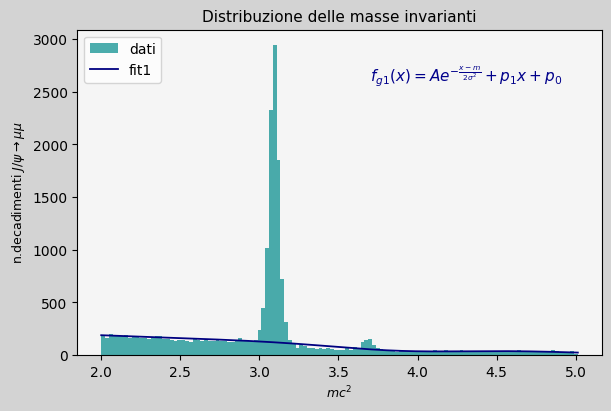

In [13]:
#Grafico Fit1
fig3, ax3 = plt.subplots(1,1, figsize=(6,4), layout='constrained', facecolor='lightgrey')
ax3.hist(d_m, bins=125, color='darkcyan', alpha=0.7, label='dati')
ax3.plot(xx, fit1, color='navy', label='fit1', linewidth=1.3)
ax3.text(3.7, 2600,r'$f_{g1}(x) = A e^{-\frac{x - m}{2 \sigma^2}} + p_1 x + p_0$', fontsize=11, family='serif',color='darkblue')
ax3.set_title('Distribuzione delle masse invarianti', fontsize=11)
ax3.set_facecolor('whitesmoke')
ax3.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=9)
ax3.set_xlabel(r'$mc^2$', fontsize=9)
ax3.legend(fontsize=10)

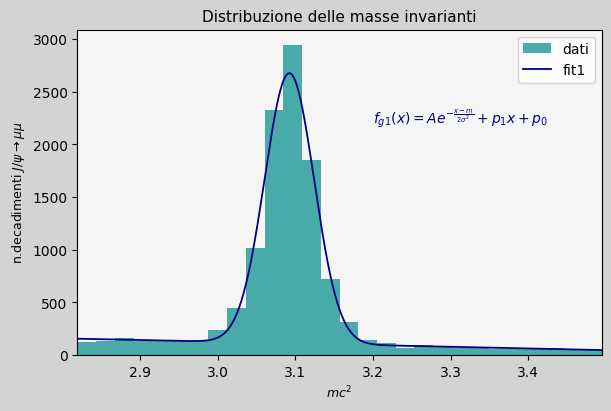

In [14]:
#Grafico Fit1 attorno al picco
fig4, ax4 = plt.subplots(1,1, figsize=(6,4), layout='constrained', facecolor='lightgrey')
ax4.hist(d_m, bins=125, color='darkcyan', alpha=0.7, label='dati')
ax4.set_xlim(binsfit[0], binsfit[-1])
ax4.plot(xx1, fit1peak, color='navy', label='fit1', linewidth=1.3)
ax4.text(3.2, 2200,r'$f_{g1}(x) = A e^{-\frac{x - m}{2 \sigma^2}} + p_1 x + p_0$', fontsize=10, family='serif',color='darkblue')
ax4.set_title('Distribuzione delle masse invarianti', fontsize=11)
ax4.set_facecolor('whitesmoke')
ax4.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=9)
ax4.set_xlabel(r'$mc^2$', fontsize=9)
ax4.legend(fontsize=10)

Test del $ \chi ^2$ per Fit1

In [15]:
fit1exp=fg1(binsfit[:-1], params2[0], params2[1], params2[2], params2[3], params2[4])
gapsfit1=(ndfit - fit1exp)
gapslfit1=(yy1-fit1peak)

In [16]:
#test del chi2
chi2fit1=np.sum((gapsfit1)**2/ndfit)

#numero di gdl
gdl1=len(ndfit) - len(params2-1)
#ch12 ridotto
chi2fit1_r=chi2fit1/gdl1

print('chi2: {:.3f} , chi2 ridotto: {:.3f} , n.grad di libertà: {:d}'.format(chi2fit1, chi2fit1_r, gdl1))

chi2: 1088.004 , chi2 ridotto: 47.305 , n.grad di libertà: 23


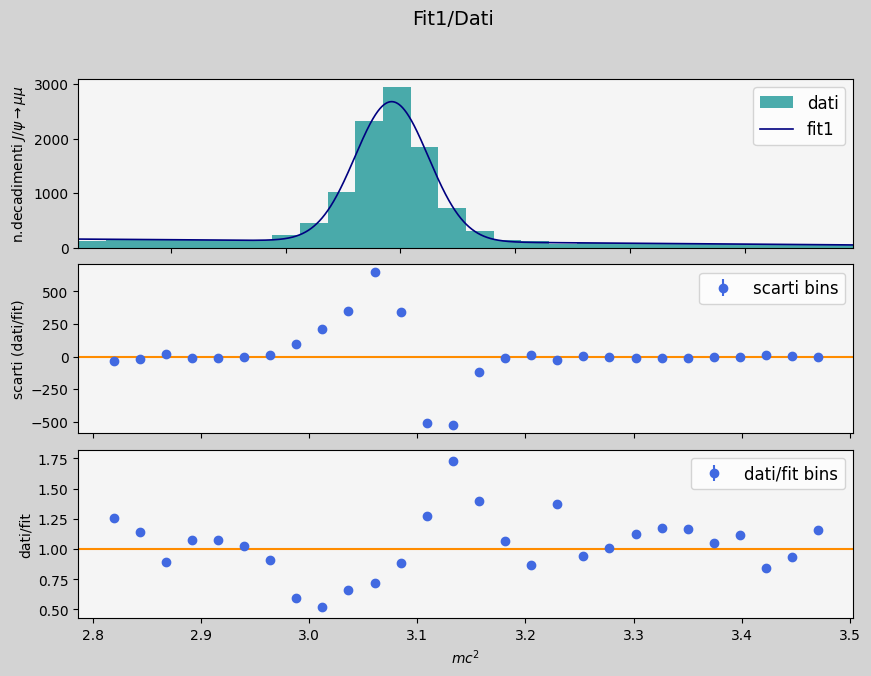

In [17]:
# grafico fit/datit
fig5 = plt.figure(figsize=(10,7), facecolor='lightgrey')
gs = fig5.add_gridspec(3,1, hspace=0.1, wspace=0)
ax5,ax6, ax7= gs.subplots()
fig5.suptitle('Fit1/Dati', fontsize=14)

#Fit
ax5.hist(d_m, bins=125, color='darkcyan', alpha=0.7, label='dati')
ax5.set_xlim(binsfit[0], binsfit[-1])
ax5.plot(xx1, fit1peak, color='navy', label='fit1', linewidth=1.2)
#ax5.text(3.7, 5800,r'$f_{g1}(x) = A e^{-\frac{x - m}{2 \sigma^2}} + p_1 x + p_0$', fontsize=12, family='serif',color='darkblue')
ax5.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=10)
ax5.set_facecolor('whitesmoke')
#ax5.tick_params('x', labelbottom=False)
ax5.legend(fontsize=12)

#Scarti
ax6.errorbar(binsfit[:-1], gapsfit1, yerr=np.abs(params2[4]), fmt='o',color ='royalblue', label='scarti bins')
#ax6.plot(xx1, gapslfit1, color='grey', label='scarti')
ax6.axhline(0, color='darkorange') 
ax6.set_ylabel('scarti (dati/fit)', fontsize=10)
ax6.set_xlabel(r'$mc^2$', fontsize=10)
ax6.set_facecolor('whitesmoke')
ax6.legend(fontsize=12)

#Scarti/errore
ax7.errorbar(binsfit[:-1], (fit1exp/ndfit), yerr=np.abs(params2[4]), fmt='o',color ='royalblue', label='dati/fit bins')
#ax7.plot(xx1, (fit1peak/yy1), color='grey', label='dati/fit')
ax7.axhline(1, color='darkorange') 
ax7.set_ylabel('dati/fit', fontsize=10)
ax7.set_xlabel(r'$mc^2$', fontsize=10)
ax7.set_facecolor('whitesmoke')
ax7.legend(fontsize=12)

for ax in fig5.get_axes():
    ax.label_outer()

### Fit 2

Ripetere l'analsi con un **Fit Doppio** come somma di due funzioni di Gauss con stessa media ma diversi sigma e normalizzazione + una polinomiale di 1° grado:

$$ f_{g2}(x) = A_1 e^{-\frac{(x - m)^2}{2 \sigma_x^2}} + A_2 e^{-\frac{(x - m)^2}{2 \sigma_x^2}} + p_1x + p_0 $$

In [18]:
#Distribuzione attesa
def fg2(x, A1=0, A2=0, m=0, p1=0, p0=0, sigma1=0, sigma2=0):
    
    """ Distribuzione Attesa Gaussiana doppia + lineare.
    
    Parametri:
    ---------
    x: array of float
        valori sui quali calcolare la distribuzione
    A1, m: float, default 1
        parametri di regressione gaussiana 1
    A2, m: float, default 1
        parametri di regressione gaussiana 1
    p0, p1: float, default 1
        parametri di regressione lineare
    
   Restituisce:
   -----------
   fit di distribuzione dei dati 
   """

    A= np.array([A1, A2])
    sigma=np.array([sigma1, sigma2])
    gauss1=np.zeros(len(x))
    gauss2=np.zeros(len(x))
    gauss=np.array([gauss1, gauss2])
    for i in range((len(A))):
        esp= -((x-m)**2)/(2*sigma[i]**2)
        term=A[i]*np.e**esp
        gauss[i]=term
    #print(gauss)
    lt=p1*x
    return gauss[0]+gauss[1]+lt+p0  

#test
f2test=fg2(d_m, 1,2,1,1,1, 1,1)

In [19]:
pstart2=np.ones(7)
params3, params3_covariance = optimize.curve_fit(fg2, xx, yy, sigma=np.sqrt(yy),absolute_sigma=True, p0=[pstart2])
err_params3=np.sqrt(params2_covariance.diagonal())
fit2=fg2(xx, params3[0], params3[1], params3[2], params3[3], params3[4], params3[5], params3[6])
#print(len(fit1))

#Stampa parametri di regressione
print('Parametri di Regressione fit2: \n')
arg1=['A1', 'A2', 'm', 'p1', 'p0','sigma1', 'sigma2']
for i,j,k in zip(arg1, params3, err_params3):
    print('{:6s}:{:>13.3f}+-{:.3f}'.format(i,j,k))

Parametri di Regressione fit2: 

A1    :      -45.747+-1.809
A2    :     -486.609+-0.000
m     :        3.878+-0.487
p1    :      -54.296+-1.591
p0    :      784.136+-0.000


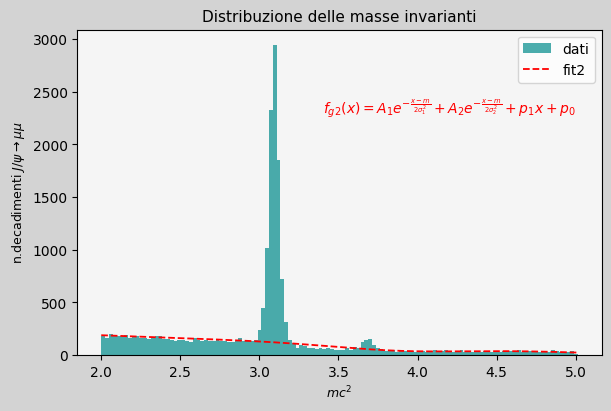

In [23]:
#Grafico Fit2
fig6, ax8 = plt.subplots(1,1, figsize=(6,4), layout='constrained', facecolor='lightgrey')
ax8.hist(d_m, bins=125, color='darkcyan', alpha=0.7, label='dati')
ax8.plot(xx, fit2, color='red', label='fit2', linewidth=1.3, linestyle='--')
ax8.text(3.4, 2300,r'$f_{g2}(x) = A_1 e^{-\frac{x - m}{2 \sigma_1^2}} + A_2 e^{-\frac{x - m}{2 \sigma_2^2}} + p_1 x + p_0$', fontsize=10, family='serif',color='red')
ax8.set_title('Distribuzione delle masse invarianti', fontsize=11)
ax8.set_facecolor('whitesmoke')
ax8.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=9)
ax8.set_xlabel(r'$mc^2$', fontsize=9)
ax8.legend(fontsize=10)

In [21]:
params4, params4_covariance = optimize.curve_fit(fg2, xx1, yy1, sigma=np.sqrt(yy1), absolute_sigma=True, p0=[pstart2])
err_params4=np.sqrt(params1_covariance.diagonal())

fit2peak=fg2(xx1, params4[0], params4[1], params4[2], params4[3], params4[4], params4[5], params4[6])

#Stampa parametri di regressione
print('Parametri di Regressione fit2 sul picco: \n')

for i,j,k in zip(arg1, params4, err_params4):
    print('{:5s}:{:9.3f}+-{:.3f}'.format(i,j,k))

Parametri di Regressione fit2 sul picco: 

A1   : 1049.142+-0.156
A2   : 1741.729+-0.002
m    :    3.092+-0.088
p1   : -142.996+-0.342
p0   :  547.175+-0.002


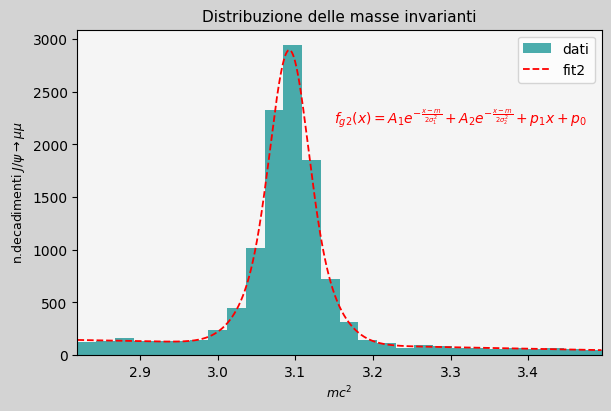

In [28]:
#Grafico Fit2 attorno al picco
fig7, ax9 = plt.subplots(1,1, figsize=(6,4), layout='constrained', facecolor='lightgrey')
ax9.hist(d_m, bins=125, color='darkcyan', alpha=0.7, label='dati')
ax9.set_xlim(binsfit[0], binsfit[-1])
ax9.plot(xx1, fit2peak, color='red', label='fit2', linewidth=1.3, linestyle='--')
ax9.text(3.15, 2200,r'$f_{g2}(x) = A_1 e^{-\frac{x - m}{2 \sigma_1^2}} + A_2 e^{-\frac{x - m}{2 \sigma_2^2}} + p_1 x + p_0$', fontsize=10, family='serif',color='red')
ax9.set_title('Distribuzione delle masse invarianti', fontsize=11)
ax9.set_facecolor('whitesmoke')
ax9.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=9)
ax9.set_xlabel(r'$mc^2$', fontsize=9)
ax9.legend(fontsize=10)

Test del $ \chi ^2$ per Fit2

In [25]:
fit2exp=fg2(binsfit[:-1], params4[0], params4[1], params4[2], params4[3], params4[4], params4[5], params4[6])
gapsfit2=(ndfit - fit2exp)
gapslfit2=(yy1-fit2peak)

In [26]:
#test del chi2
chi2fit2=np.sum((gapsfit2)**2/ndfit)

#numero di gdl
gdl2=len(ndfit) - len(params4-1)
#ch12 ridotto
chi2fit2_r=chi2fit2/gdl2

print('chi2: {:.3f} , chi2 ridotto: {:.3f} , n.grad di libertà: {:d}'.format(chi2fit2, chi2fit2_r, gdl2))

chi2: 990.213 , chi2 ridotto: 47.153 , n.grad di libertà: 21


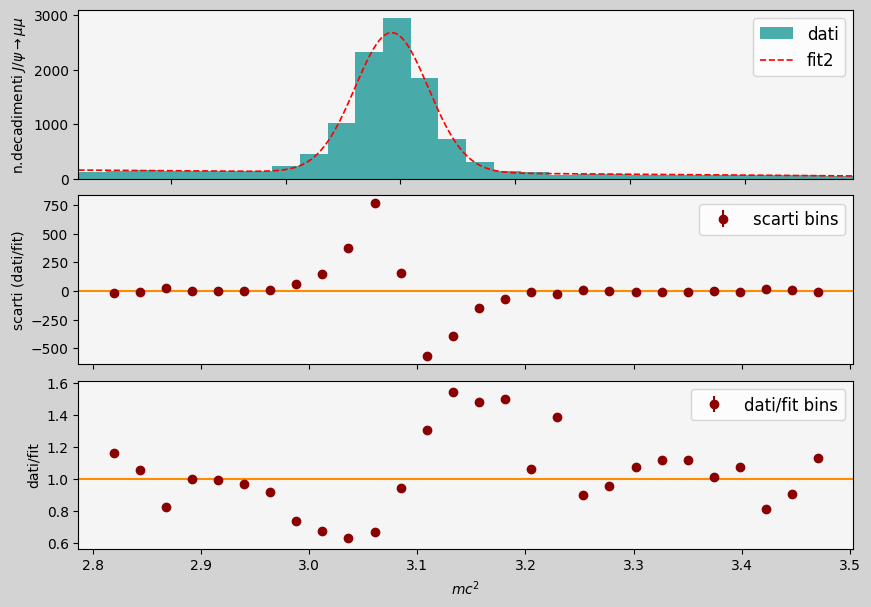

In [31]:
# grafico fit/datit
fig8 = plt.figure(figsize=(10,7), facecolor='lightgrey')
gs = fig8.add_gridspec(3,1, hspace=0.1, wspace=0)
ax10,ax11, ax12= gs.subplots()
fig5.suptitle('Fit2/Dati', fontsize=14)

#Fit
ax10.hist(d_m, bins=125, color='darkcyan', alpha=0.7, label='dati')
ax10.set_xlim(binsfit[0], binsfit[-1])
ax10.plot(xx1, fit1peak, color='red', label='fit2', linewidth=1.2, linestyle='--')
#ax10.text(3.7, 5800,r'$f_{g1}(x) = A e^{-\frac{x - m}{2 \sigma^2}} + p_1 x + p_0$', fontsize=12, family='serif',color='darkblue')
ax10.set_ylabel('n.decadimenti '+r'$J/\psi \rightarrow \mu \mu $', fontsize=10)
ax10.set_facecolor('whitesmoke')
#ax10.tick_params('x', labelbottom=False)
ax10.legend(fontsize=12)

#Scarti
ax11.errorbar(binsfit[:-1], gapsfit2, yerr=np.abs(params4[6]), fmt='o',color ='darkred', label='scarti bins')
#ax11.plot(xx1, gapslfit2, color='grey', label='scarti')
ax11.axhline(0, color='darkorange') 
ax11.set_ylabel('scarti (dati/fit)', fontsize=10)
ax11.set_xlabel(r'$mc^2$', fontsize=10)
ax11.set_facecolor('whitesmoke')
ax11.legend(fontsize=12)

#Scarti/errore
ax12.errorbar(binsfit[:-1], (fit2exp/ndfit), yerr=np.abs(params4[6]), fmt='o',color ='darkred', label='dati/fit bins')
#ax12.plot(xx1, (fit2peak/yy1), color='grey', label='dati/fit')
ax12.axhline(1, color='darkorange') 
ax12.set_ylabel('dati/fit', fontsize=10)
ax12.set_xlabel(r'$mc^2$', fontsize=10)
ax12.set_facecolor('whitesmoke')
ax12.legend(fontsize=12)

for ax in fig8.get_axes():
    ax.label_outer()

**Opzionale**: Ripetere l'analisi per il picco a più alta energia. Di che particella potrebbe trattarsi?

$ J/ \psi (1S):$
$$ \quad \text{MASS:} \; 3096.900 \pm 0.006 \; \text{MeV} \qquad \text{WIDTH:} \; 92.6 \pm 1.7 \; \text{keV}$$